In [13]:
import os
import sys
import glob
sys.path.insert(0, "/project/def-nahee/kbas/Graphnet-Applications/Metadata")
import paths
from icecube import icetray

import pandas as pd
from collections import Counter


from icecube import LeptonInjector, simclasses, dataclasses, dataio 


import numpy as np
import matplotlib.pyplot as plt

icetray.I3Logger.global_logger = icetray.I3NullLogger()

In [14]:
DATASET = "SPRING2026MC"

In [15]:
all_datasets = {
    name: val for name, val in vars(paths).items()
    if not name.startswith("_") and isinstance(val, dict)
    and all(isinstance(v, dict) for v in val.values())
}

In [16]:


full_geo = selected_datasets["SPRING2026MC_I3"]["full_geometry"]

def get_energies(path, fmt):
    energies = []
    files = sorted(glob.glob(f"{path}/**/*.i3.{fmt}", recursive=True))
    for f in files:
        i3file = dataio.I3File(f)
        for frame in i3file:
            if frame.Stop != icetray.I3Frame.DAQ:
                continue
            try:
                mctree = frame["I3MCTree"]
                primary = mctree.primaries[0]
                energies.append(primary.energy)
            except:
                continue
        i3file.close()
    return np.array(energies)

energies = {}
for flavor, info in full_geo.items():
    print(f"Reading {flavor}...")
    energies[flavor] = get_energies(info["path"], info["format"])
    print(f"  {len(energies[flavor])} events")


Reading Muon...


  7444 events
Reading Electron...
  4192 events
Reading Tau...
  5581 events
Reading NC...
  9074 events


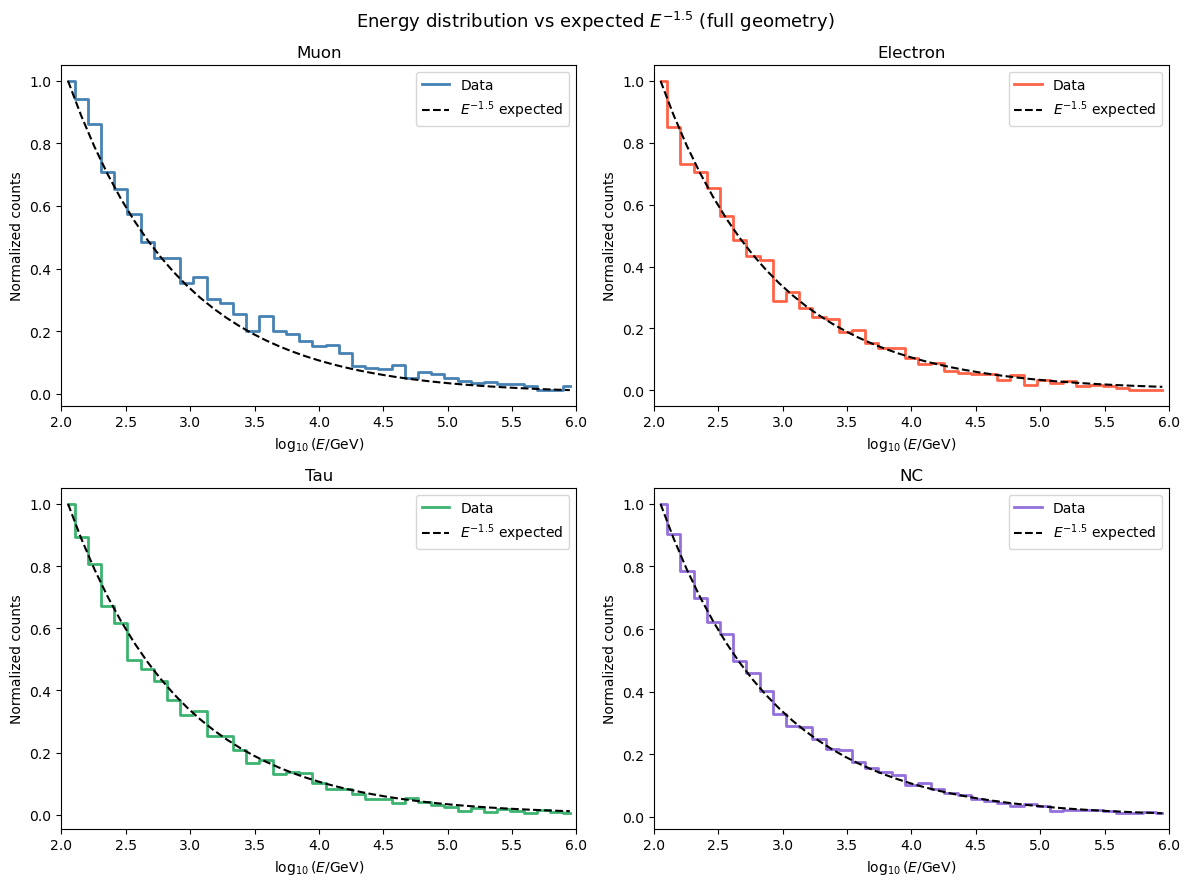

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

colors = {"Muon": "steelblue", "Electron": "tomato", "Tau": "mediumseagreen", "NC": "mediumpurple"}

for ax, (flavor, E) in zip(axes, energies.items()):
    log_E = np.log10(E)
    bins = np.linspace(2, 6, 40)

    counts, edges = np.histogram(log_E, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # normalize to compare shape
    counts_norm = counts / counts.max()

    # expected E^-1.5 shape in log bins: dN/d(logE) ~ E^-1.5 * E * ln(10) ~ E^-0.5
    E_centers = 10**centers
    expected = E_centers**(-0.5)
    expected_norm = expected / expected.max()

    ax.step(centers, counts_norm, where="mid", color=colors[flavor], label="Data", linewidth=2)
    ax.plot(centers, expected_norm, "k--", label=r"$E^{-1.5}$ expected", linewidth=1.5)

    ax.set_xlabel(r"$\log_{10}(E/\mathrm{GeV})$")
    ax.set_ylabel("Normalized counts")
    ax.set_title(flavor)
    ax.legend()
    ax.set_xlim(2, 6)

plt.suptitle("Energy distribution vs expected $E^{-1.5}$ (full geometry)", fontsize=13)
plt.tight_layout()
plt.savefig("energy_distribution_full_geometry.png", dpi=150)
plt.show()
